In [1]:
#Downloading the model
!wget -O hand_landmarker.task https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

--2026-07-10 06:59:45--  https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.101.207, 142.250.141.207, 142.251.2.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.101.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7819105 (7.5M) [application/octet-stream]
Saving to: ‘hand_landmarker.task’

hand_landmarker.tas 100%[===================>]   7.46M  --.-KB/s    in 0.03s   

2026-07-10 06:59:45 (265 MB/s) - ‘hand_landmarker.task’ saved [7819105/7819105]



In [2]:
import os
print(os.path.exists("hand_landmarker.task"))

True


In [4]:
!pip install mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 12.5 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [5]:
#information in mediapipe library
import mediapipe as mp

print(mp.__version__)
print(dir(mp))

0.10.35
['Image', 'ImageFormat', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'tasks']


In [6]:
#Initialize the Hand Landmarker
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

base_options = python.BaseOptions(model_asset_path="hand_landmarker.task")

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=2
)

detector = vision.HandLandmarker.create_from_options(options)

print("MediaPipe Hand Landmarker Initialized Successfully!")

MediaPipe Hand Landmarker Initialized Successfully!


In [13]:
import os

print(os.listdir())

['.config', 'hand_landmarker.task', 'sample_data']


In [14]:
from google.colab import files

uploaded = files.upload()

Saving hands.zip to hands.zip


In [15]:
import zipfile

with zipfile.ZipFile("hands.zip", "r") as zip_ref:
    zip_ref.extractall("hands")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [17]:
#Confirming  image location
import os

for root, dirs, files in os.walk("hands"):
    print(root)
    print("Files:", len(files))
    if len(files) > 0:
        print("First 5 files:", files[:5])
    print("-"*40)

hands
Files: 1
First 5 files: ['HandInfo.csv']
----------------------------------------
hands/Hands
Files: 0
----------------------------------------
hands/Hands/Hands
Files: 11076
First 5 files: ['Hand_0002567.jpg', 'Hand_0001234.jpg', 'Hand_0008956.jpg', 'Hand_0010468.jpg', 'Hand_0001158.jpg']
----------------------------------------


In [18]:
image_path = "hands/Hands/Hands/Hand_0000002.jpg"

import os
print(os.path.exists(image_path))


True


In [19]:
#Creating a MediaPipe Image
mp_image = mp.Image.create_from_file(image_path)

print("Image loaded successfully!")

Image loaded successfully!


In [20]:
#detecting Hand Landmarks
detection_result = detector.detect(mp_image)

print("Hands Detected:", len(detection_result.hand_landmarks))

Hands Detected: 1


In [27]:
# Counting the number of landmarks detected

if len(detection_result.hand_landmarks) > 0:
    print("Number of hands detected:", len(detection_result.hand_landmarks))
    print("Number of landmarks on the first hand:", len(detection_result.hand_landmarks[0]))
else:
    print("No hands detected.")

Number of hands detected: 1
Number of landmarks on the first hand: 21


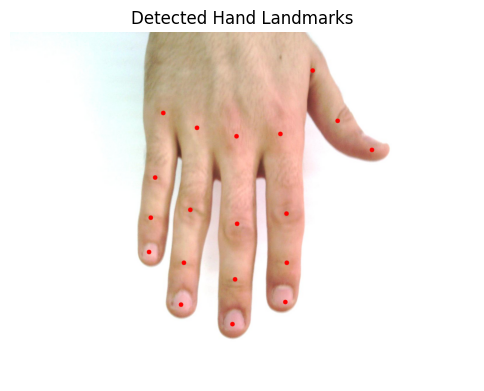

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mediapipe.tasks.python.vision.core.vision_task_running_mode import VisionTaskRunningMode

# Read image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get image dimensions
height, width, _ = image.shape

# Draw landmarks
for hand_landmarks in detection_result.hand_landmarks:

    # Draw landmark points
    for landmark in hand_landmarks:
        x = int(landmark.x * width)
        y = int(landmark.y * height)
        cv2.circle(image, (x, y), 8, (255,0,0), -1)

# Display image
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Detected Hand Landmarks")
plt.axis("off")
plt.show()

#Summary

In this exploration, I learned how the MediaPipe Hands library works for hand landmark detection. I installed the library, loaded a hand image from our dataset, and successfully detected the hand using the Hand Landmarker model. The model identified 21 landmark points on the hand, representing the wrist and finger joints. This experiment showed that MediaPipe can accurately detect hand features from images. These landmarks can be useful for extracting hand features in the later stages of our AI-based palmistry project.